## Open Exploration

*Kleine intro over wat er in dit bestand gebeurd*

In [1]:
import pandas as pd
import networkx as nx
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# make sure pandas is version 1.0 or higher
# make sure networkx is version 2.4 or higher
print(pd.__version__)
print(nx.__version__)

2.2.3
3.4.2


In [3]:
from ema_workbench import (Model, Policy, ema_logging, SequentialEvaluator, MultiprocessingEvaluator, perform_experiments)

from problem_formulation import get_model_for_problem_formulation, sum_over, sum_over_time

In [4]:
ema_logging.log_to_stderr(ema_logging.INFO)

# choose problem formulation number, between 0-5
# each problem formulation has its own list of outcomes
dike_model, planning_steps = get_model_for_problem_formulation(2)

In [5]:
def get_do_nothing_dict():
    return {l.name:0 for l in dike_model.levers}

# Define 4 policies
policies = [
    # Do nothing
    Policy("Base case", **{l.name: 0 for l in dike_model.levers}),

    # Increase dike height with 5 dm every decision step
    Policy("Dikes only", **dict(get_do_nothing_dict(), **{
        'A.1_DikeIncrease 0': 5, 'A.1_DikeIncrease 1': 5, 'A.1_DikeIncrease 2': 5,
        'A.2_DikeIncrease 0': 5, 'A.2_DikeIncrease 1': 5, 'A.2_DikeIncrease 2': 5,
        'A.3_DikeIncrease 0': 5, 'A.3_DikeIncrease 1': 5, 'A.3_DikeIncrease 2': 5,
        'A.4_DikeIncrease 0': 5, 'A.4_DikeIncrease 1': 5, 'A.4_DikeIncrease 2': 5,
        'A.5_DikeIncrease 0': 5, 'A.5_DikeIncrease 1': 5, 'A.5_DikeIncrease 2': 5
    })),

    # Implement RfR on all locations at all decision steps
    Policy("RfR only", **dict(get_do_nothing_dict(), **{
        '0_RfR 0': 1, '0_RfR 1': 1, '0_RfR 2': 1,
        '1_RfR 0': 1, '1_RfR 1': 1, '1_RfR 2': 1,
        '2_RfR 0': 1, '2_RfR 1': 1, '2_RfR 2': 1,
        '3_RfR 0': 1, '3_RfR 1': 1, '3_RfR 2': 1,
        '4_RfR 0': 1, '4_RfR 1': 1, '4_RfR 2': 1,
        '5_RfR 0': 1, '5_RfR 1': 1, '5_RfR 2': 1,
        '6_RfR 0': 1, '6_RfR 1': 1, '6_RfR 2': 1
    })),

    #
    Policy('Proposal debate 1', **dict(get_do_nothing_dict(), **{
        'A.1_DikeIncrease 0': 0, 'A.1_DikeIncrease 1': 0, 'A.1_DikeIncrease 2': 0,
        'A.2_DikeIncrease 0': 0, 'A.2_DikeIncrease 1': 0, 'A.2_DikeIncrease 2': 0,
        'A.3_DikeIncrease 0': 0, 'A.3_DikeIncrease 1': 0, 'A.3_DikeIncrease 2': 0,
        'A.4_DikeIncrease 0': 0, 'A.4_DikeIncrease 1': 0, 'A.4_DikeIncrease 2': 0,
        'A.5_DikeIncrease 0': 0, 'A.5_DikeIncrease 1': 0, 'A.5_DikeIncrease 2': 0,
        '0_RfR 0': 1, '0_RfR 1': 1, '0_RfR 2': 1,
        '2_RfR 0': 1, '2_RfR 1': 1, '2_RfR 2': 1
    }))
]

In [6]:
n_scenarios = 1000 # misschien aanpassen naar 500??

# running the model through EMA workbench
with MultiprocessingEvaluator(dike_model) as evaluator:
    results = evaluator.perform_experiments(n_scenarios, policies)

[MainProcess/INFO] pool started with 18 workers
[MainProcess/INFO] performing 1000 scenarios * 4 policies * 1 model(s) = 4000 experiments
100%|██████████████████████████████████████| 4000/4000 [02:39<00:00, 25.14it/s]
[MainProcess/INFO] experiments finished
[MainProcess/INFO] terminating pool


In [25]:
# CHAT code om de waarden van de uncertainties te vinden. Nog zorgen dat dit opgeslagen wordt, zodat het gebruikt kan worden in de scenario_MORDM.ipynb file

import pandas as pd
import numpy as np

uncertainties = [unc.name for unc in dike_model.uncertainties]

# Unpack results
experiments, outcomes = results

# Convert 'Expected Number of Deaths' outcome into a DataFrame
deaths = pd.DataFrame(outcomes['Expected Number of Deaths'])

# Add scenario and policy info
deaths['scenario'] = experiments.index
deaths['policy'] = experiments['policy']

# Sum deaths across locations/years (if multi-dimensional)
deaths['total_deaths'] = deaths.drop(columns=['scenario', 'policy']).sum(axis=1)

# Find the scenarios with max and min deaths
max_idx = deaths['total_deaths'].idxmax()
min_idx = deaths['total_deaths'].idxmin()

# Get the corresponding experiment rows (lever values and uncertainties)
max_experiment = experiments.loc[max_idx]
min_experiment = experiments.loc[min_idx]

# Print results
print("⚠️ Highest number of deaths:")
print(f"Policy: {max_experiment['policy']}, Scenario index: {max_idx}")
print(f"Total deaths: {deaths.loc[max_idx]['total_deaths']}")
print("\nLever settings for highest death scenario:")
print(max_experiment[uncertainties])  # drop policy label for clarity

print("\n" + "-"*80 + "\n")

print("✅ Lowest number of deaths:")
print(f"Policy: {min_experiment['policy']}, Scenario index: {min_idx}")
print(f"Total deaths: {deaths.loc[min_idx]['total_deaths']}")
print("\nLever settings for lowest death scenario:")
print(min_experiment[uncertainties])

⚠️ Highest number of deaths:
Policy: Base case, Scenario index: 527
Total deaths: 4.710330543236399

Lever settings for highest death scenario:
discount rate 0                   1.5
discount rate 1                   1.5
discount rate 2                   1.5
A.0_ID flood wave shape           121
A.1_Bmax                    34.379598
A.1_pfail                    0.036385
A.1_Brate                         1.5
A.2_Bmax                   114.357298
A.2_pfail                    0.506002
A.2_Brate                         1.5
A.3_Bmax                   120.897864
A.3_pfail                    0.137992
A.3_Brate                         1.0
A.4_Bmax                   205.548125
A.4_pfail                    0.386802
A.4_Brate                         1.5
A.5_Bmax                    88.740367
A.5_pfail                    0.042538
A.5_Brate                        10.0
Name: 527, dtype: object

--------------------------------------------------------------------------------

✅ Lowest number of deaths:

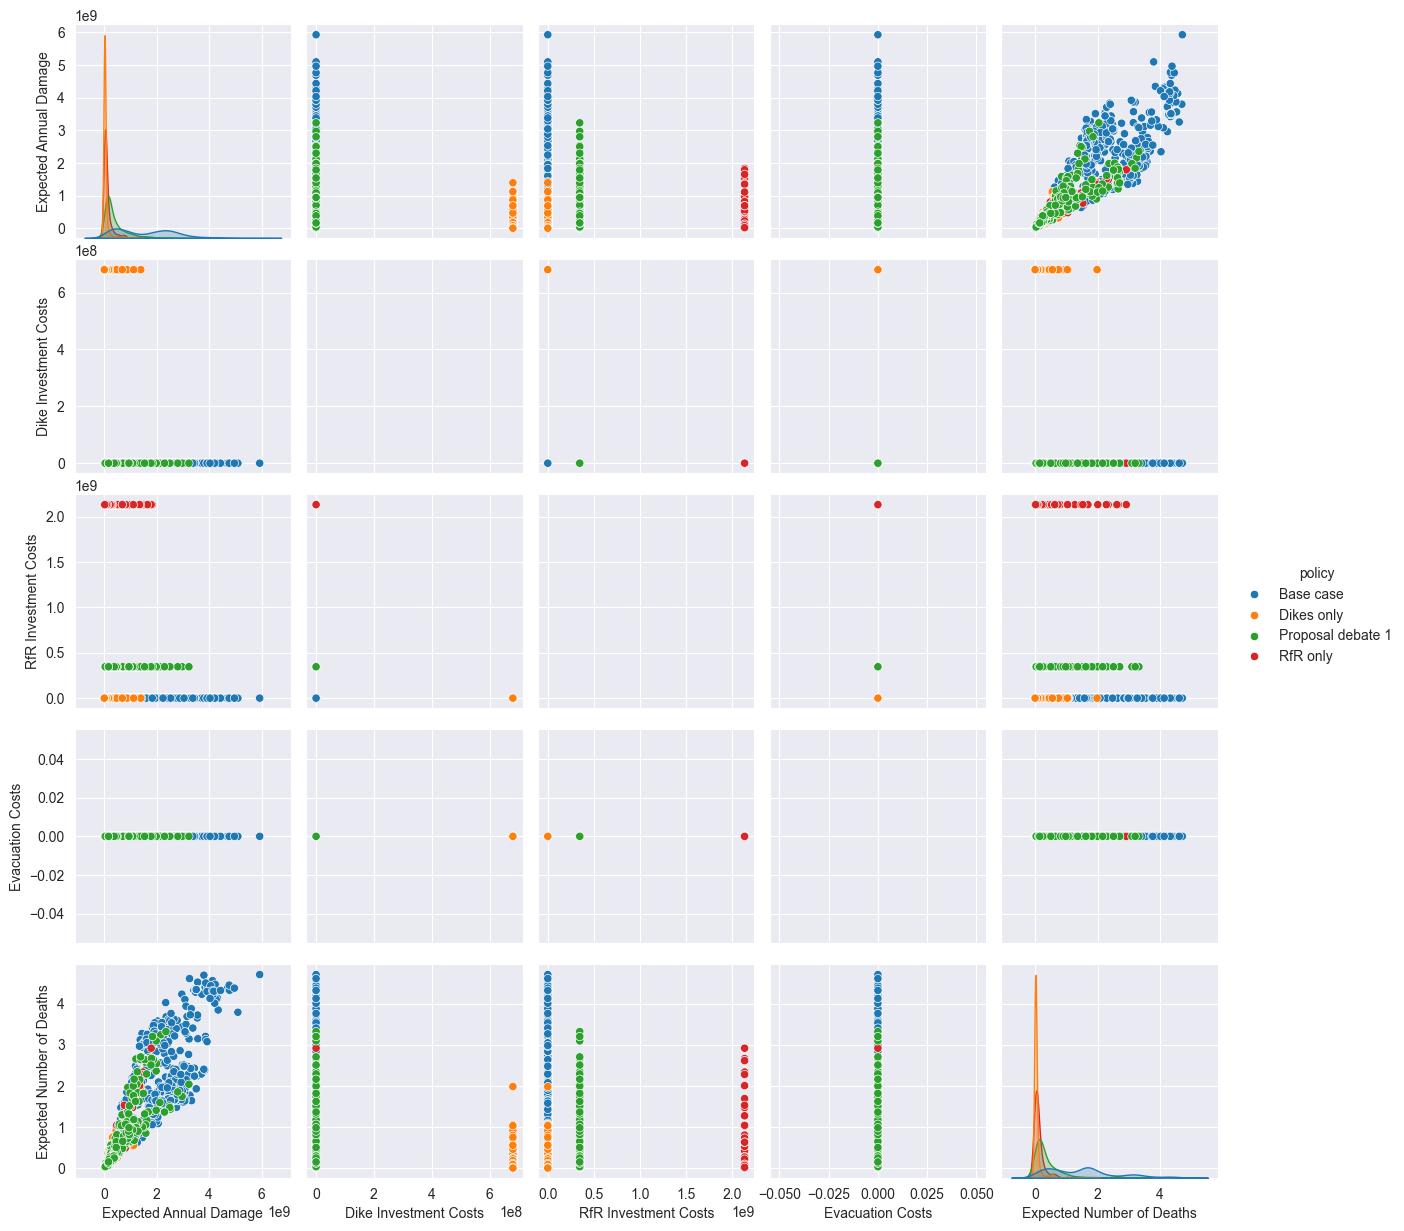

In [7]:
experiments, outcomes = results
policies = experiments['policy']

data = pd.DataFrame.from_dict(outcomes)
data['policy'] = policies

plot = sns.pairplot(data, hue='policy', vars=outcomes.keys(), )
#plot.savefig("open_exp.png")
plt.show()